**Import Libraries**

In [2]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from PIL import Image, UnidentifiedImageError

**Dataset path**

In [3]:
# Define dataset path
train_dir = "/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train"

**Get the class names**

In [4]:
# Get class names (subdirectories)
class_names = sorted(os.listdir(train_dir))
if not class_names:
  print("No class directories found in the train folder!")
else:
  print(f"Found {len(class_names)} classes: {class_names}")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


**Check the corrupted images**

In [5]:
corrupted_images = []
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = os.listdir(class_path)
    for img_name in images:
      img_path = os.path.join(class_path, img_name)
      try:
        with Image.open(img_path) as img:
          img.verify()
      except (IOError, SyntaxError) as e:
          corrupted_images.append(img_path)
if corrupted_images:
  print(f"\nCorrupted Images Found:")
  for img_path in corrupted_images:
    print(img_path)
else:
  print("\nNo corrupted images found.")



Corrupted Images Found:
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images (2).jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images (13).jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images (9).jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/download (1).jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images.jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images (7).jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images (4).jpeg
/content/drive/MyDrive/COLLEGE/Colab Notebooks/AI AND MACHINE LEARNING/week6/FruitinAmazon/train/cupuacu/images (6).jpeg
/content

**Check the class distribution**

In [6]:
class_counts = {}

for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path)
                  if img.lower().endswith(('.png','.jpg','.jpeg'))]
    class_counts[class_name] = len(images)

print("\nClass Distribution:")
for k, v in class_counts.items():
    print(k, ":", v)


Class Distribution:


**Show the random images**

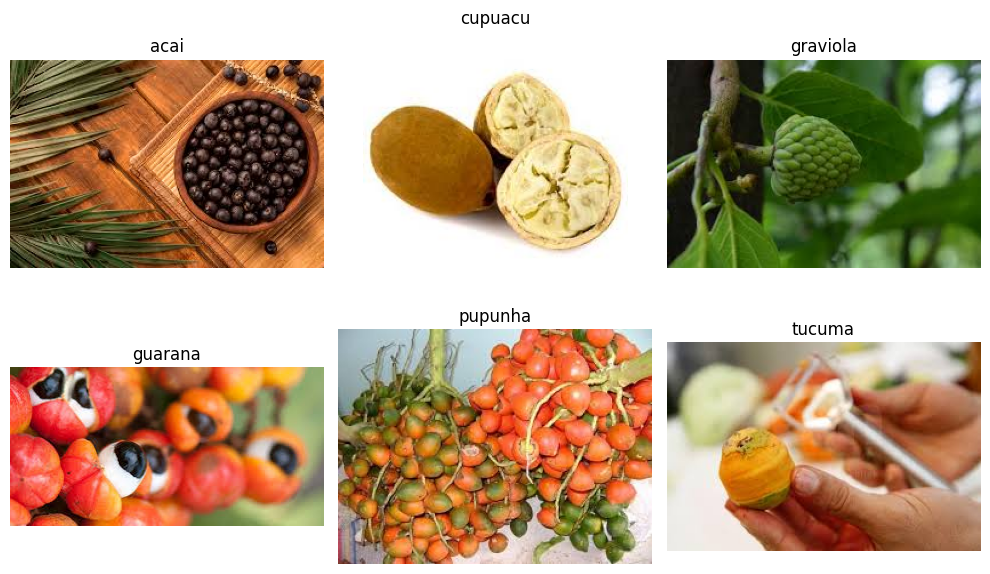

In [8]:
selected_images = []
selected_labels = []

for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)

    images = [img for img in os.listdir(class_path)
              if img.lower().endswith(('.png','.jpg','.jpeg'))]

    if images:
        img = random.choice(images)
        selected_images.append(os.path.join(class_path, img))
        selected_labels.append(class_name)

# Plot
plt.figure(figsize=(10,6))
for i in range(len(selected_images)):
    img = plt.imread(selected_images[i])
    plt.subplot(2, (len(selected_images)+1)//2, i+1)
    plt.imshow(img)
    plt.title(selected_labels[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

**load the dataset**

In [9]:
image_size = (224, 224)
batch_size = 32

train_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=image_size,
    batch_size=batch_size
)

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


Data Augumentation

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

Build CNN Model (with BN + Dropout)

In [11]:
num_classes = len(class_names)

model = keras.Sequential([

    layers.Input(shape=(224,224,3)),

    data_augmentation,
    layers.Rescaling(1./255),

    # Block 1
    layers.Conv2D(32, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 2
    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Block 3
    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),
    layers.Dropout(0.25),

    # Dense Layers
    layers.Flatten(),

    layers.Dense(512),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(256),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),

    layers.Dense(num_classes, activation='softmax')
])

Compile Model

In [12]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

Train Model

In [13]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 7s/step - accuracy: 0.2500 - loss: 1.9872 - val_accuracy: 0.0556 - val_loss: 2.0942
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 39s 8s/step - accuracy: 0.4722 - loss: 1.3951 - val_accuracy: 0.1111 - val_loss: 1.8306
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 6s/step - accuracy: 0.4028 - loss: 1.5381 - val_accuracy: 0.1667 - val_loss: 1.8374
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 27s 8s/step - accuracy: 0.5139 - loss: 1.3927 - val_accuracy: 0.1667 - val_loss: 2.3667
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 6s/step - accuracy: 0.5556 - loss: 1.2894 - val_accuracy: 0.1667 - val_loss: 3.0477
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.5278 - loss: 1.1243 - val_accuracy: 0.1667 - val_loss: 3.4737
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 5s/step - accuracy: 0.6806 - loss: 1.0330 - val_accuracy: 0.1667 - val_loss: 3.7236
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 19s 5s/step - accuracy: 0.6806 - loss: 0.7916 - val_accuracy: 0.1667 - val_loss: 4.0111
Epoch 9/

Evaluate Model

In [14]:
loss, acc = model.evaluate(val_ds)
print("Validation Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 689ms/step - accuracy: 0.1667 - loss: 4.3027
Validation Accuracy: 0.1666666716337204


Make Predictions

In [15]:
for images, labels in val_ds.take(1):
    preds = model.predict(images)
    predicted_labels = np.argmax(preds, axis=1)

    print("Predicted:", predicted_labels[:5])
    print("Actual:   ", labels[:5].numpy())

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 854ms/step
Predicted: [2 2 2 2 2]
Actual:    [3 4 3 4 3]


Transfer Learning with VGG16

Load Pretrained Model

In [16]:
from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Freeze Layers

In [17]:
for layer in base_model.layers:
    layer.trainable = False

Add Custom Layers

In [18]:
x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(512, activation='relu')(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)

**Create Model**

In [19]:
model_tl = keras.Model(inputs=base_model.input, outputs=outputs)

Compile & Train

In [20]:
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 69s 23s/step - accuracy: 0.2083 - loss: 6.4488 - val_accuracy: 0.1667 - val_loss: 10.7148
Epoch 2/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 61s 20s/step - accuracy: 0.4583 - loss: 5.7737 - val_accuracy: 0.2778 - val_loss: 6.5786
Epoch 3/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 68s 24s/step - accuracy: 0.7778 - loss: 1.0876 - val_accuracy: 0.4444 - val_loss: 3.9816
Epoch 4/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 58s 19s/step - accuracy: 0.9306 - loss: 0.2085 - val_accuracy: 0.4444 - val_loss: 5.5218
Epoch 5/5
3/3 ━━━━━━━━━━━━━━━━━━━━ 64s 22s/step - accuracy: 0.8333 - loss: 0.3681 - val_accuracy: 0.6111 - val_loss: 4.8771


**Evaluation**

In [21]:
from sklearn.metrics import classification_report

y_pred = model.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)

# true labels
y_true = np.concatenate([y for x, y in val_ds], axis=0)

print(classification_report(y_true, y_pred_classes))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         1
           1       0.00      0.00      0.00         2
           2       0.17      1.00      0.29         3
           3       0.00      0.00      0.00         5
           4       0.00      0.00      0.00         4
           5       0.00      0.00      0.00         3

    accuracy                           0.17        18
   macro avg       0.03      0.17      0.05        18
weighted avg       0.03      0.17      0.05        18



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The transfer learning model (VGG16) performed better than the CNN trained from scratch.

Reason:
- VGG16 is pre-trained on ImageNet dataset
- It already learned useful image features like edges, textures, shapes
- Therefore, it requires less training data and gives higher accuracy